# Parts II/III: Baseline Models (M4)

Persistence vs ridge vs LightGBM on the June panel, under the exact protocol
of notebook 03: five purged walk-forward folds, 60-minute embargo,
standardization on train statistics only, LightGBM trained with vega sample
weights. Everything below recomputes live from the surface states and closely
reproduces the registered June skill table in the memo. Provenance deltas,
stated rather than hidden: the live panel is 897,532 cell-minutes and 35
features, versus the registered June run's 886,467 cell-minutes and its
smaller pre-trade-flow feature set; the surface builder and feature layer
have both grown since that run, so skills differ from the registered table
by up to about one point.

The evaluation convention matters as much as the model: the headline metric
is MSE **skill versus persistence** (1 - MSE_model / MSE_persistence),
reported both plain and vega-weighted.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The research library and data live in the (private) qfdev_research repo,
# checked out as a sibling of this showcase repo. Override with QFDEV_RESEARCH.
RESEARCH = os.path.abspath(os.environ.get('QFDEV_RESEARCH', '../../qfdev_research'))
assert os.path.isdir(os.path.join(RESEARCH, 'quant')), RESEARCH
sys.path.insert(0, RESEARCH)

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.width', 160)

from quant.forecasting import config as C
from quant.forecasting import baselines, evaluate
from quant.forecasting.data import load_panel
from quant.forecasting.labels import add_forward_div_labels
from quant.forecasting.features import add_features, feature_columns
from quant.forecasting.splits import walk_forward_splits

SURFACE_ROOT = os.path.join(RESEARCH, 'quant', 'surface', 'out')
DAYS = sorted(os.path.basename(os.path.dirname(p)) for p in
              glob.glob(os.path.join(SURFACE_ROOT, 'spy_202606*', 'surface_state_1m.parquet')))
panel = load_panel(DAYS, SURFACE_ROOT)
panel = add_forward_div_labels(panel, C.HORIZONS_MIN)
panel = add_features(panel)
panel['vega'] = baselines.approx_vega(panel)
feat_cols = feature_columns(panel)
print(f"{len(DAYS)} sessions | {len(panel):,} cell-minutes | {len(feat_cols)} features")
print(feat_cols)

21 sessions | 897,532 cell-minutes | 35 features
['iv', 'rel_spread', 'n', 'log_moneyness', 'dte_bucket', 'delta', 'qimb', 'ofi', 'ofi_roll_sum', 'ofi_sum_30m', 'ofi_ewma_30m', 'ofi_mom', 'qimb_mean_30m', 'qimb_lag5m', 'qimb_lag15m', 'qimb_lag30m', 'signed_vol', 'svol_sum_30m', 'svol_ewma_30m', 'svol_mom', 'svol_share_30m', 'tr_vol_sum_30m', 'atm_iv', 'skew', 'fly', 'term_slope_atm', 'iv_roll_std', 'minutes_since_open', 'iv_chg_1m', 'iv_chg_5m', 'iv_chg_15m', 'ret_1m', 'ret_5m', 'ret_15m', 'realized_vol']


## Walk-forward fit

For each horizon and fold: ridge and LightGBM fit on train, predict test;
persistence predicts zero. Predictions are pooled across folds and scored
once per (model, horizon).

In [2]:
def run_horizon(h, collect=False, imp_accum=None):
    data = panel.dropna(subset=feat_cols + [f'dIV_{h}m'])
    yt, rp, lp, pp, vg, extra = [], [], [], [], [], []
    for tr_m, te_m in walk_forward_splits(data['minute'], C.N_SPLITS, C.EMBARGO_MIN):
        tr = data[data['minute'].isin(tr_m)]; te = data[data['minute'].isin(te_m)]
        if len(tr) < 50 or len(te) == 0:
            continue
        X_tr, y_tr = tr[feat_cols].to_numpy(), tr[f'dIV_{h}m'].to_numpy()
        ridge = baselines.make_ridge(C.RIDGE_ALPHA).fit(X_tr, y_tr)
        gbm = baselines.make_lgbm()
        gbm.fit(X_tr, y_tr,
                sample_weight=tr['vega'].to_numpy() if C.LGBM_VEGA_WEIGHT else None)
        X_te = te[feat_cols].to_numpy()
        yt.append(te[f'dIV_{h}m'].to_numpy()); rp.append(ridge.predict(X_te))
        lp.append(gbm.predict(X_te)); pp.append(baselines.persistence_predict(len(te)))
        vg.append(te['vega'].to_numpy())
        if collect:
            extra.append(te[['dte_bucket', 'moneyness_bucket']])
        if imp_accum is not None:
            imp_accum += gbm.booster_.feature_importance(importance_type='gain')
    y, r, l, p, w = map(np.concatenate, (yt, rp, lp, pp, vg))
    out = []
    pers = evaluate.regression_metrics(y, p, vega=w); pers['skill'] = 0.0
    for name, pred in [('persistence', p), ('ridge', r), ('lgbm', l)]:
        m = evaluate.regression_metrics(y, pred, vega=w)
        m['skill'] = evaluate.skill_vs_persistence(m['mse'], pers['mse'])
        m.update(horizon=h, model=name)
        out.append(m)
    coll = (y, r, l, w, pd.concat(extra, ignore_index=True)) if collect else None
    return out, coll

lgbm_imp = np.zeros(len(feat_cols))
rows, prim = [], None
for hz in C.HORIZONS_MIN:
    res, coll = run_horizon(hz, collect=(hz == C.PRIMARY_HORIZON_MIN), imp_accum=lgbm_imp)
    rows.extend(res)
    if coll is not None:
        prim = coll

summary = evaluate.summarize(rows)
display(summary.style.format('{:.4f}', subset=[c for c in summary.columns
        if c not in ('horizon', 'model', 'n')]))

,horizon,model,n,mse,vw_mse,rmse,mae,dir_acc,ic_pearson,ic_rank,skill
2,5,lgbm,672258,0.0002,0.0000,0.0143,0.0053,0.5787,0.4714,0.2379,0.2163
0,5,persistence,672258,0.0003,0.0001,0.0161,0.0056,0.0000,nan,nan,0.0000
1,5,ridge,672258,0.0002,0.0000,0.0140,0.0053,0.5732,0.4929,0.2404,0.2434
5,15,lgbm,654097,0.0003,0.0001,0.0166,0.0074,0.5520,0.4625,0.1868,0.2015
3,15,persistence,654097,0.0003,0.0001,0.0185,0.0073,0.0000,nan,nan,0.0000
4,15,ridge,654097,0.0003,0.0001,0.0161,0.0069,0.5646,0.4960,0.2211,0.2487
8,30,lgbm,626908,0.0003,0.0001,0.0187,0.0090,0.5461,0.4479,0.1670,0.1780
6,30,persistence,626908,0.0004,0.0001,0.0206,0.0087,0.0000,nan,nan,0.0000
7,30,ridge,626908,0.0003,0.0001,0.0180,0.0085,0.5411,0.4821,0.1654,0.2385
11,60,lgbm,572542,0.0005,0.0002,0.0228,0.0123,0.5461,0.4984,0.1927,0.2103


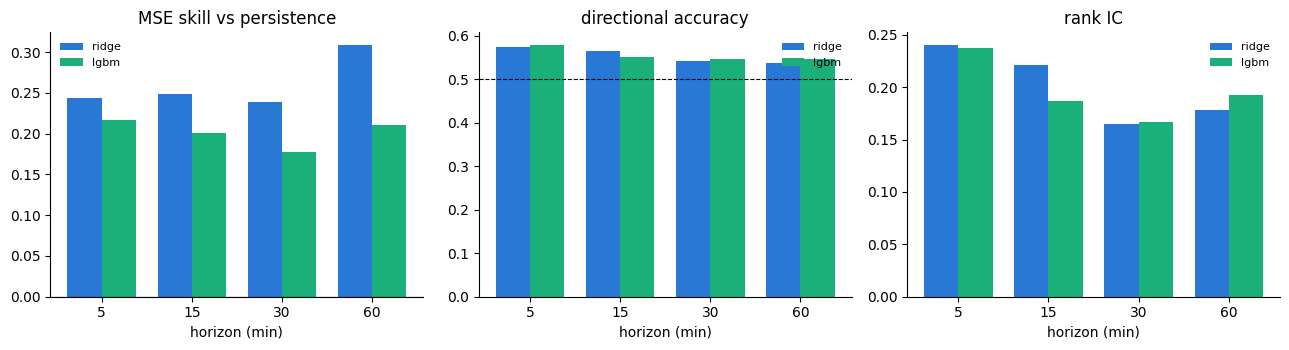

In [3]:
piv = summary.pivot(index='horizon', columns='model')
x = np.arange(len(piv.index)); wd = 0.38
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for j, (mdl, col) in enumerate([('ridge', '#2a78d6'), ('lgbm', '#1baf7a')]):
    off = (j - 0.5) * wd
    ax[0].bar(x + off, piv[('skill', mdl)], wd, label=mdl, color=col)
    ax[1].bar(x + off, piv[('dir_acc', mdl)], wd, label=mdl, color=col)
    ax[2].bar(x + off, piv[('ic_rank', mdl)], wd, label=mdl, color=col)
for a, t in zip(ax, ['MSE skill vs persistence', 'directional accuracy', 'rank IC']):
    a.set_xticks(x, piv.index.astype(str)); a.set_xlabel('horizon (min)')
    a.set_title(t); a.legend(frameon=False, fontsize=8)
    a.spines[['top', 'right']].set_visible(False)
ax[0].axhline(0, color='k', lw=0.8)
ax[1].axhline(0.5, color='k', lw=0.8, ls='--')
plt.tight_layout()

Ridge matches or beats LightGBM on plain MSE at every horizon: the dominant
signal (short-term IV mean reversion, visible in the feature chart below) is
linear. The honest per-cell edge is directional accuracy in the high 50s at
short horizons and the rank IC. Note the rank IC plotted here is **pooled**
over all cells and minutes; the per-minute cross-sectional rank IC quoted in
the memo (+0.40 in the tradeable scope) is a separate per-minute calculation
and is the market-making-native statement. Pooled Pearson correlations ride
the common ATM factor and are quoted nowhere.

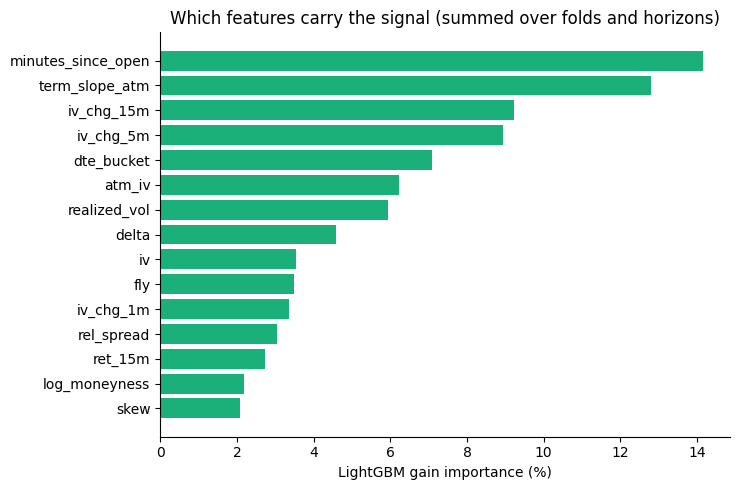

In [4]:
fi = (pd.DataFrame({'feature': feat_cols, 'gain_pct': 100 * lgbm_imp / lgbm_imp.sum()})
      .sort_values('gain_pct', ascending=False).head(15)[::-1])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(fi['feature'], fi['gain_pct'], color='#1baf7a')
ax.set_xlabel('LightGBM gain importance (%)')
ax.set_title('Which features carry the signal (summed over folds and horizons)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

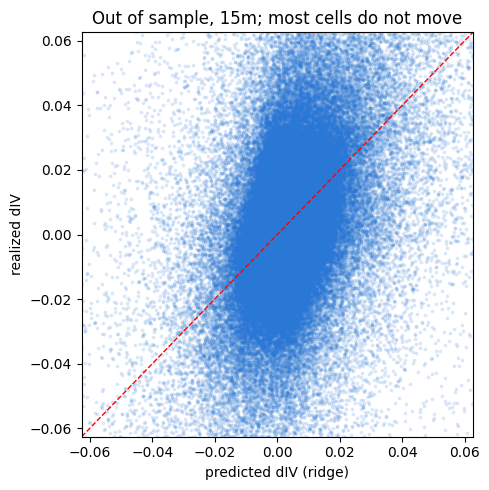

In [5]:
y, r, l, w, meta = prim
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(r, y, s=3, alpha=0.12, color='#2a78d6')
lim = np.nanpercentile(np.abs(np.concatenate([y, r])), 99)
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('predicted dIV (ridge)'); ax.set_ylabel('realized dIV')
ax.set_title(f'Out of sample, {C.PRIMARY_HORIZON_MIN}m; most cells do not move')
plt.tight_layout()

## The aggregate hides a smile of skill

Vega-weighted skill by surface region (ridge, 15 minutes, computed from the
pooled out-of-sample predictions above). Skill concentrates in short-DTE
wings and is negative through the ATM body and the longer-dated surface,
which runs almost exactly opposite to vega. This is why the tradeable scope
was locked in advance to expiries within 7 days, off the immediate ATM
point, and why vega-weighted aggregates are quoted alongside plain ones.

,region,vega-weighted skill
0,DTE 1-7,0.209
1,DTE 14-21,-0.132
2,DTE 30-45,-0.276
3,ATM |k|<=0.005,-0.133
4,near wing,0.085
5,far wing |k|>0.025,0.232


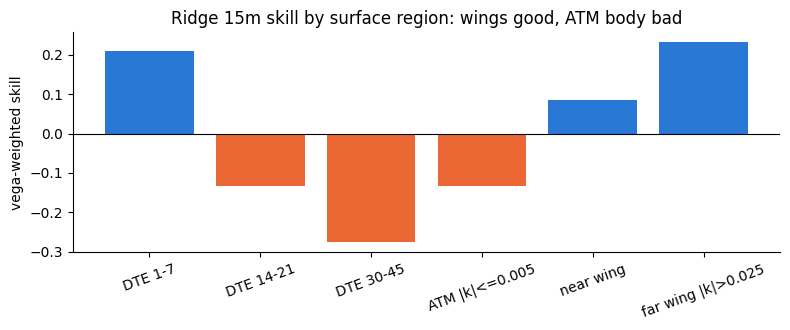

In [6]:
def wskill(mask):
    yy, rr, ww = y[mask], r[mask], w[mask]
    if len(yy) < 500:
        return np.nan
    mse_m = np.average((yy - rr) ** 2, weights=ww)
    mse_p = np.average(yy ** 2, weights=ww)
    return 1 - mse_m / mse_p

dte = meta['dte_bucket'].to_numpy(); k = meta['moneyness_bucket'].abs().to_numpy()
regions = pd.DataFrame([
    ('DTE 1-7',   wskill(dte <= 7)),
    ('DTE 14-21', wskill((dte >= 14) & (dte <= 21))),
    ('DTE 30-45', wskill(dte >= 30)),
    ('ATM |k|<=0.005',  wskill(k <= 0.005)),
    ('near wing',       wskill((k > 0.005) & (k <= 0.025))),
    ('far wing |k|>0.025', wskill(k > 0.025)),
], columns=['region', 'vega-weighted skill'])
display(regions.round(3))

fig, ax = plt.subplots(figsize=(8, 3.4))
colors = ['#2a78d6' if v >= 0 else '#eb6834' for v in regions['vega-weighted skill']]
ax.bar(regions['region'], regions['vega-weighted skill'], color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('vega-weighted skill'); plt.xticks(rotation=20)
ax.set_title('Ridge 15m skill by surface region: wings good, ATM body bad')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## Read-out

The signal is real, mostly linear, and geographically concentrated. On the
expanded three-month panel (which contains June, so an expanded-sample
robustness check rather than an independent replication) the headline
conclusions hold (ridge 15m plain skill 0.261), while the June
feature-ablation signs did **not** all survive the re-test; that reversal,
and what it implies about single-month findings, is Section 5 of the memo. The next notebook asks whether a deep
sequence model finds anything these baselines miss.